## Предсказание вероятности клика


**Задача**  

Построить модель бинарной классификации, которая предсказывает вероятность клика (CTR) на рекламное объявление. Нужно провести калибровку этой модели, чтобы обеспечить соответствие между предсказанными вероятностями и фактической частотой кликов.


# Структура проекта


1. Идентификаторы и временные метки  
**id** — уникальный идентификатор записи о показе баннера  
**hour** — час, в который был показан баннер, в формате YYMMDDHH

 2. Характеристики рекламной площадки (Site)  
**site_id** — идентификатор веб-сайта, на котором был показан баннер  
**site_domain** — домен веб-сайта  
**site_category** — тематическая категория веб-сайта  

 3. Характеристики рекламируемого приложения (App)  
**app_id** — идентификатор рекламируемого мобильного приложения  
**app_domain** — домен рекламируемого приложения  
**app_category** — категория рекламируемого приложения

 4. Характеристики устройства и соединения пользователя  
**device_id** — идентификатор браузера или устройства  
**device_ip** — IP-адрес устройства  
**device_model** — модель устройства  
**device_type** — тип устройства пользователя: например, смартфон, планшет, ПК  
**device_conn_type** — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G

 5. Характеристики рекламного баннера и аукциона  
**C1** — анонимизированный признак, характеризующий контекст показа  
**banner_pos** — позиция баннера на веб-странице  
**C14** — **C21** — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона

 6. Машинно-сгенерированные признаки (ML Features)  
**ml_feature_1**, **ml_feature_3** — **ml_feature_6**, **ml_feature_8** — **ml_feature_10** — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков  
**ml_feature_2**, **ml_feature_7** — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков

 7. Целевая переменная  
**click** — бинарный признак, указывающий, был ли совершён клик по баннеру. **1** — клик был, **0** — клика не было.


## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.


In [27]:
!pip install ydata-profiling
!pip install Pillow==9.5.0 -q

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
from ydata_profiling import ProfileReport
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder, FunctionTransformer, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.feature_selection import (SelectKBest, chi2, f_classif, mutual_info_classif,
                                       RFE, RFECV, SelectFromModel,VarianceThreshold)
from sklearn.svm import SVC
from IPython.display import display
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
                             roc_auc_score, confusion_matrix,brier_score_loss, brier_score_loss,
                             roc_curve, precision_recall_curve,average_precision_score,log_loss)



In [19]:
import joblib
!pip install category_encoders -q
from category_encoders import TargetEncoder

!pip install phik -q
from phik import phik_matrix

In [20]:
RANDOM_STATE = 42

df = pd.read_csv('/datasets/ds_s16_ad_click_dataset.csv', sep = ',', decimal=".")

display(df.head(10))

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909
5,1.037910e+19,1,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.386621,D,-2.561220,1,-0.327084,0.997424,Y,-0.718630,0.063355,0.118050
6,1.046962e+19,0,14102100,1005,0,543a539e,c7ca3108,3e814130,ecad2386,7801e8d9,...,-1.029484,B,0.616779,0,-0.088135,-0.484160,Y,0.390766,0.399371,0.278207
7,1.048718e+19,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,fbbccc58,2347f47a,...,-1.412949,A,0.667451,0,0.010914,-0.607470,Y,0.216093,0.746051,0.439438
8,1.056080e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-1.841339,C,-8.415390,0,-0.774189,-0.957543,Z,-0.230077,0.574167,-0.054031
9,1.081451e+19,1,14102100,1005,1,e59ef3fc,0a4015b2,335d28a8,ecad2386,7801e8d9,...,-1.098406,D,6.310419,0,1.930692,-0.980213,Y,-0.354278,0.372335,0.321687


>-Импортированны необходимые библиотеки  
-Данные загруженны корректно, проблем не обнаружено


## 2. Исследовательский анализ данных (EDA)

#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.

#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.


In [29]:
profile = ProfileReport(df, title="AutoValue Train EDA")
profile.to_file("train_report.html")

/opt/conda/lib/python3.9/site-packages/ydata_profiling/profile_report.py:365: UserWarning: Try running command: 'pip install --upgrade Pillow' to avoid ValueError
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 34/34 [00:04<00:00,  7.55it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

ValueError: Only supported for TrueType fonts

<Figure size 432x288 with 0 Axes>

In [21]:
print(df.shape)

(50000, 34)


In [22]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64 

>-Всего 50000 строк в датафрейме.  
-Некоторые типы данных нужно изменить - например, тип устройства - численный, а нужно сделать категориальным.  
-Пропусков нет.


In [23]:
list_cat = ['banner_pos','device_type','C16', 'C15', 'C1', 'device_conn_type','C19'] 
for i in list_cat:
    df[i] = df[i].astype('category')
    print(df[i].dtype)

category
category
category
category
category
category
category


In [24]:
print(df['click'].value_counts())

click
0    41397
1     8603
Name: count, dtype: int64


In [25]:
print(df['click'].value_counts(normalize=True))

click
0    0.82794
1    0.17206
Name: proportion, dtype: float64


>41397(82%) - не нажали на рекламу  
8603(18%) - нажали на рекламу  
Наблюдаем дисбаланс в целевой переменной


In [9]:
num_features = df.select_dtypes(include=['int64','float64']).columns
print(num_features)
cat_features = df.select_dtypes(include=['object','category']).columns
print(cat_features)

Index(['id', 'click', 'hour', 'C14', 'C17', 'C18', 'C20', 'C21',
       'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
       'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'],
      dtype='object')
Index(['C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id',
       'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model',
       'device_type', 'device_conn_type', 'C15', 'C16', 'C19', 'ml_feature_2',
       'ml_feature_7'],
      dtype='object')


> Все признаки с ID и IP будут мешаться при обучении модели их стоит сразу удалить, а остальные признаки нужно изучить


In [10]:
df = df.drop(columns=['id','site_id','app_id','device_id','device_ip'])
print(df.columns)

Index(['click', 'hour', 'C1', 'banner_pos', 'site_domain', 'site_category',
       'app_domain', 'app_category', 'device_model', 'device_type',
       'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20',
       'C21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4',
       'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8',
       'ml_feature_9', 'ml_feature_10'],
      dtype='object')


In [11]:
num_features = df.select_dtypes(include=['int64','float64']).columns
cat_features = df.select_dtypes(include=['object','category']).columns

print(df[cat_features].nunique())

C1                     7
banner_pos             7
site_domain         1013
site_category         18
app_domain            67
app_category          22
device_model        2521
device_type            4
device_conn_type       4
C15                    8
C16                    9
C19                   64
ml_feature_2           5
ml_feature_7           3
dtype: int64


>Для всех категориальных признаков где категорий больше чем 10 я бы предпочёл использовать LabelEncoder или TargetEncoder, а для признаков с малым количеством категорий OneHotEncoder


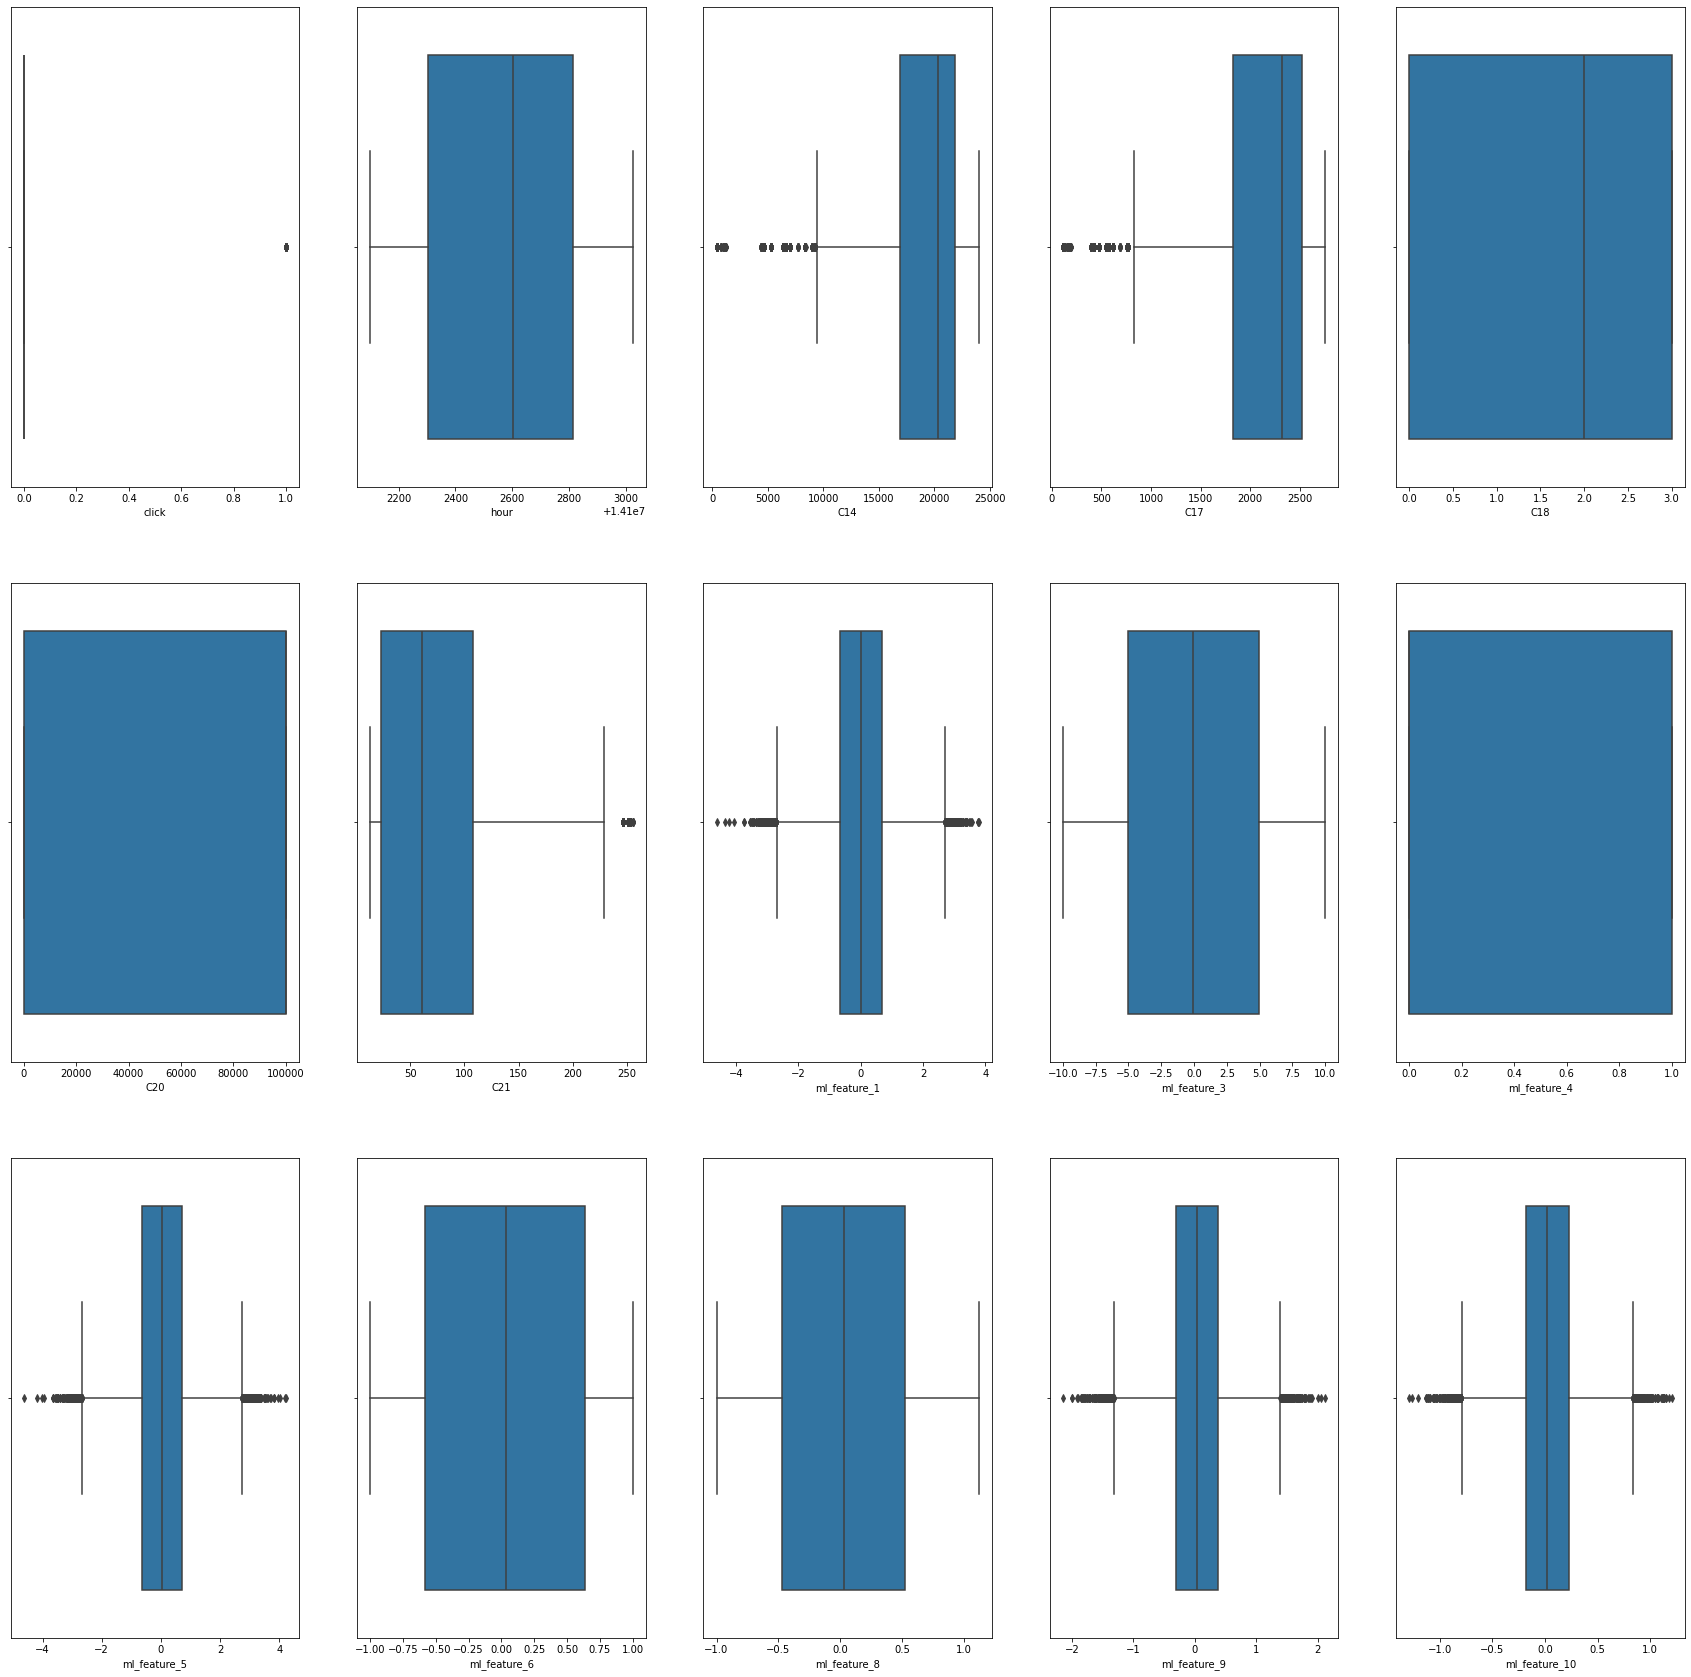

In [12]:

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(30, 30))


for i, feature in enumerate(num_features):
    row = i // 5 
    col = i % 5
    sns.boxplot(x=feature, data=df, ax=axes[row, col])

plt.show()

>На данном этапе с выбросами ничего не будем делать, в дальнейшем сгладим их спомощью извлечения корня


In [13]:
#corr_phix = phik_matrix(df)
#plt.figure(figsize=(20,10))
#sns.heatmap(corr_phix, annot=True)
#plt.title('Heatmap корреляции')
#plt.show()

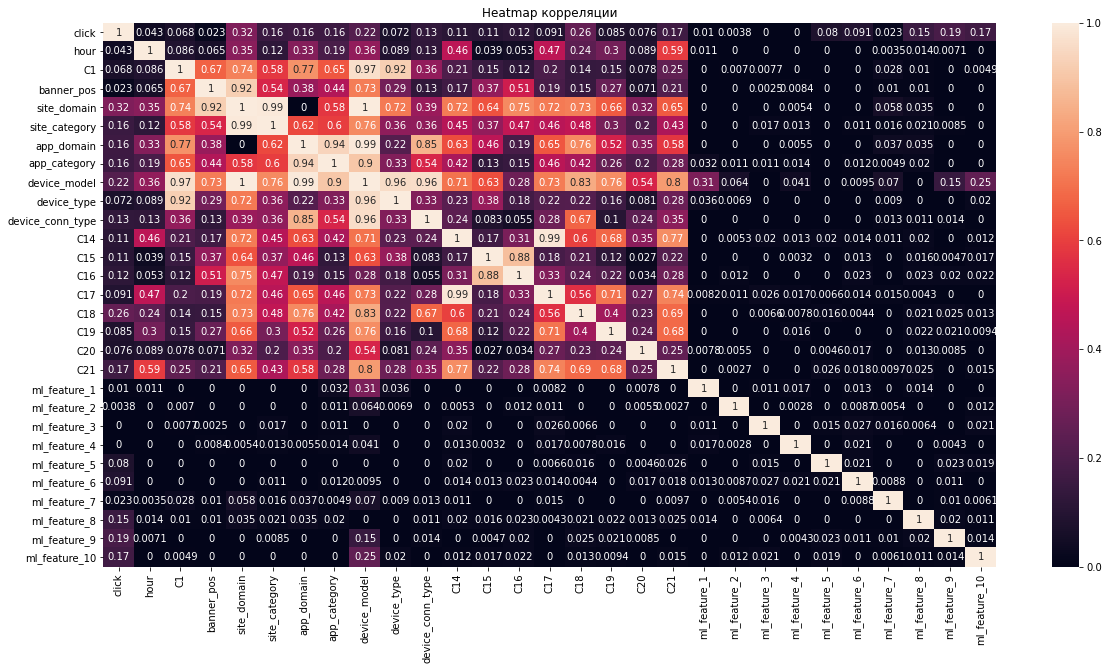


>>Коментирую код из за долгих вычислений и прикрепляю изображение результатов (работаспособность кода можно проверить разкоментировав код)


> Сто процентов нужно будет удалять признаки с нулевой корреляцией и при меньше 3%

>А также удалить данные с большой коррелцие во избежание проблемы мультиколениальности,


In [14]:
df = df.drop(columns=['ml_feature_3','ml_feature_4','ml_feature_1','ml_feature_2','ml_feature_7','banner_pos'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   click             50000 non-null  int64   
 1   hour              50000 non-null  int64   
 2   C1                50000 non-null  category
 3   site_domain       50000 non-null  object  
 4   site_category     50000 non-null  object  
 5   app_domain        50000 non-null  object  
 6   app_category      50000 non-null  object  
 7   device_model      50000 non-null  object  
 8   device_type       50000 non-null  category
 9   device_conn_type  50000 non-null  category
 10  C14               50000 non-null  int64   
 11  C15               50000 non-null  category
 12  C16               50000 non-null  category
 13  C17               50000 non-null  int64   
 14  C18               50000 non-null  int64   
 15  C19               50000 non-null  category
 16  C20               5000

In [15]:
df = df.drop(columns=['site_domain','device_model','C1','app_domain','C17','C15','C19'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   click             50000 non-null  int64   
 1   hour              50000 non-null  int64   
 2   site_category     50000 non-null  object  
 3   app_category      50000 non-null  object  
 4   device_type       50000 non-null  category
 5   device_conn_type  50000 non-null  category
 6   C14               50000 non-null  int64   
 7   C16               50000 non-null  category
 8   C18               50000 non-null  int64   
 9   C20               50000 non-null  int64   
 10  C21               50000 non-null  int64   
 11  ml_feature_5      50000 non-null  float64 
 12  ml_feature_6      50000 non-null  float64 
 13  ml_feature_8      50000 non-null  float64 
 14  ml_feature_9      50000 non-null  float64 
 15  ml_feature_10     50000 non-null  float64 
dtypes: category(3), float6

In [16]:
corr_phix = phik_matrix(df)
plt.figure(figsize=(20,10))
sns.heatmap(corr_phix, annot=True)
plt.title('Heatmap корреляции')
plt.show()

interval columns not set, guessing: ['click', 'hour', 'C14', 'C18', 'C20', 'C21', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']


KeyboardInterrupt: 

Выводы
>50 000 строк данных  
Целевая переменная с дисбалансом 18%   
Скорректированны типы данных где это необходимо   
Пропуски отсутствуют  
Удалены некоторые признаки - признаки с ID/IP, с малой корреляцией, признаки вызывающие мультиколлинеарность


## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.


In [ ]:
X = df.drop(columns='click')
y = df['click']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, shuffle=True, stratify=y, random_state=RANDOM_STATE)


print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

>Данные разделенны корректно  
Целевая переменная распределена по выборкам корректно


## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!


In [ ]:
num_features = X_train.select_dtypes(include=['int64','float64']).columns
cat_features = X_train.select_dtypes(include=['object','category']).columns

cat_features_OH = []
cat_features_TE = []

for i in cat_features:
    counter = X_train[i].nunique()
    
    if counter <= 10:
        cat_features_OH.append(i)
    else:
        cat_features_TE.append(i)
        
print(cat_features_OH)
print(cat_features_TE)

In [ ]:
sqrt_transformer = FunctionTransformer(lambda x: np.sqrt(np.abs(x)))

>Создал FunctionTransformer для пайплайна с числовыми признаками


In [ ]:
cat_OH_pipeline = Pipeline([
    ('cat_OH', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

cat_TE_pipeline = Pipeline([
    ('cat_TE', TargetEncoder())
])

num_scaler_pipeline = Pipeline([
    ('sqrt', sqrt_transformer),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('cat_OH',cat_OH_pipeline,cat_features_OH),
    ('cat_TE',cat_TE_pipeline,cat_features_TE),
    ('scaler',num_scaler_pipeline,num_features)
])

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.


>Сортировку по корреляции я сделал ранее


In [ ]:

X_train_processed = preprocessor.fit_transform(X_train, y_train)


selector_var = VarianceThreshold(threshold=0.01)
X_train_var = selector_var.fit_transform(X_train_processed)



n_features = X_train_var.shape[1]
mi_selector = SelectKBest(score_func=mutual_info_classif, k=min(30, n_features))
X_train_mi = mi_selector.fit_transform(X_train_processed, y_train)


In [ ]:
rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    step=2,
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1
)

rfecv.fit(X_train_processed, y_train)
X_train_selected = rfecv.transform(X_train_processed)
final_n_features = X_train_selected.shape[1]


In [ ]:
print('Количество признаков до обработки')
print(X_train.shape[1])
print('Количество признаков после препроцессора')
print(X_train_processed.shape[1])
print('Количество признаков после VarianceThreshold')
print(X_train_var.shape[1])
print('Количество признаков после SelectKBest')
print(X_train_mi.shape[1])
print('Количество признаков после обёртки RFECV')
print(final_n_features)

>Некоторые выводы по обработке признаков:  
-Из 29 признаков оставили 18 признаков, неплохой результат  
-Все лишние признаки отсеялись сразу на этапе с VarianceThreshold, последующие действия не вызвали изменение результата


## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.


In [ ]:
scoring = {
    'PR_AUC': 'average_precision',
    'Precision': 'precision',
    'Recall': 'recall',
    'F1-score': 'f1'
} 

dummy = DummyClassifier(strategy='prior')

logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)

svc = SVC(kernel='linear',probability=False)

stf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)

In [ ]:
logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('variance', selector_var),
    ('mi_selection', mi_selector),
    ('classifier', logreg)
])
scores_logreg = cross_validate(logreg_pipeline, X_train, y_train, cv=stf, scoring=scoring)

In [ ]:
svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('variance', selector_var),
    ('mi_selection', mi_selector),
    ('classifier', svc)
])
scores_svc = cross_validate(svc_pipeline, X_train, y_train, cv=stf, scoring=scoring)

In [ ]:
scores_dummy = cross_validate(dummy, X_train, y_train, cv=stf, scoring=scoring)

In [ ]:
print(scores_dummy['test_PR_AUC'].mean())
print(scores_logreg['test_PR_AUC'].mean())
print(scores_svc['test_PR_AUC'].mean())

>Выводы:  
Dummy (базовая бодель) - 0.17   
Результаты логистической регресси и SVC лучше базовой модели. 
Log.reg. - 0.26 (лучше базовой модели на 0.09)  
SVC - 0.21 (лучше базовой модели на 0.04)


## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.


>>Коментирую код из за долгих вычислений и прикрепляю изображение результатов + тексом (работаспособность кода можно проверить разкоментировав код)


In [ ]:
param_grid_logreg = {
    'classifier__C': [0.1, 1, 10],  
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': [None]  
}

param_grid_svc = {
    'classifier__kernel': ['linear'],
    'classifier__C': [0.1, 1, 10],
    'classifier__class_weight': [None, 'balanced']
}

In [ ]:
#grid_logreg = GridSearchCV(
#    logreg_pipeline,
#    param_grid_logreg,
#    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
#    scoring='average_precision',
#    n_jobs=-1,
#    verbose=1
#)

#grid_logreg.fit(X_train, y_train)

#print("Лучшие параметры LogisticRegression:")
#print(grid_logreg.best_params_)
#print(f"Лучший PR-AUC: {grid_logreg.best_score_:.4f}")

>Лучшие параметры LogisticRegression:
{'classifier__C': 10, 'classifier__class_weight': None, 'classifier__penalty': 'l2'}
Лучший PR-AUC: 0.2677


In [ ]:
#grid_svc = GridSearchCV(
#    svc_pipeline,
#    param_grid_svc,
#    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
#    scoring='average_precision',
#    n_jobs=-1,
#    verbose=1
#)

#grid_svc.fit(X_train, y_train)

#print("Лучшие параметры SVC:")
#print(grid_svc.best_params_)
#print(f"Лучший PR-AUC: {grid_svc.best_score_:.4f}")

>Лучшие параметры SVC:  
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__kernel': 'linear'}
Лучший PR-AUC: 0.2517


In [ ]:
#print("LOGISTIC REGRESSION TOP-10:")
#logreg_results = pd.DataFrame(grid_logreg.cv_results_).sort_values('mean_test_score', ascending=False)[['params', 'mean_test_score', 'std_test_score']]
#display(logreg_results.head(10))

#print("SVC TOP-10:")
#svc_results = pd.DataFrame(grid_svc.cv_results_).sort_values('mean_test_score', ascending=False)[['params', 'mean_test_score', 'std_test_score']]
#display(svc_results.head(10))

#print(f"LogReg best: {grid_logreg.best_params_} | PR-AUC: {grid_logreg.best_score_:.4f}")
#print(f"SVC best: {grid_svc.best_params_} | PR-AUC: {grid_svc.best_score_:.4f}")

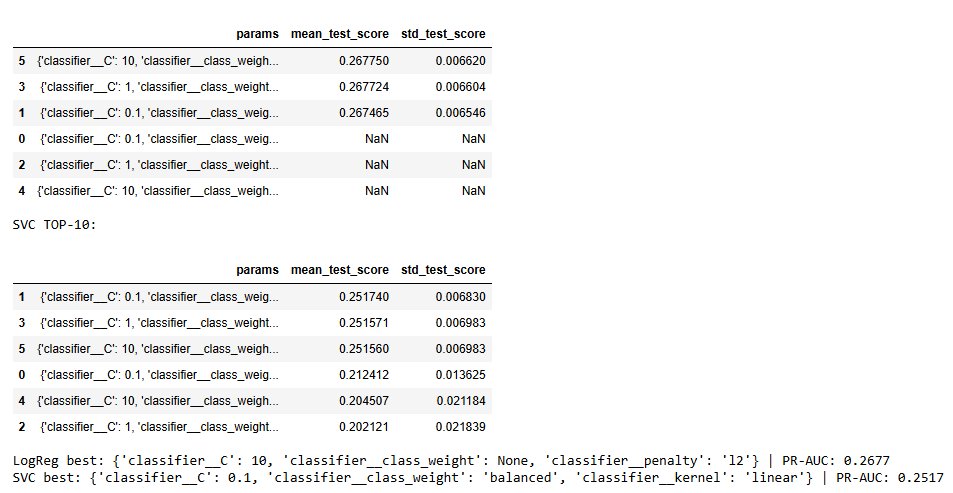


>LogReg best: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__penalty': 'l2'} | PR-AUC: 0.2677  
SVC best: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__kernel': 'linear'} | PR-AUC: 0.2517


>Лучшая модель со следующими параметрами : LogReg best: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__penalty': 'l2'} - PR-AUC: 0.2677


## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.


In [ ]:
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('variance', selector_var),
    ('mi_selection', mi_selector),
    ('classifier', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE,C=10,class_weight=None,penalty='l2'))
])

final_pipeline.fit(X_train, y_train)

y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_pred = final_pipeline.predict(X_test)

pr_auc = average_precision_score(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)
logloss = log_loss(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ")
print(f"PR-AUC (average precision): {pr_auc:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"Log Loss: {logloss:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

In [ ]:
oh_features = []
for i, cat in enumerate(cat_features_OH):
    unique_vals = sorted(X_train[cat].unique())
    for val in unique_vals:
        oh_features.append(f"{cat}_{val}")

all_features = oh_features + cat_features_TE + list(num_features)

preprocessed_data = preprocessor.fit_transform(X_train, y_train)
var_mask = selector_var.fit(preprocessed_data).get_support()
var_features = [all_features[i] for i in range(len(all_features)) if var_mask[i]]

mi_mask = mi_selector.fit(preprocessed_data[:, var_mask], y_train).get_support()
final_features = [var_features[i] for i in range(len(var_features)) if mi_mask[i]]

coefficients = final_pipeline.named_steps['classifier'].coef_[0]

weights_df = pd.DataFrame({
    'feature': final_features,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)


print("ТОП-10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ")
display(weights_df.head(10))

>ИНТЕРПРЕТАЦИЯ  
1. PR-AUC = 0.2595: Модель хорошо ранжирует клики выше не-кликов  
2. Brier Score = 0.1378: Среднеквадратичная ошибка вероятностей  
3. Precision = 0.5357: 53.6% предсказанных кликов верны  
4. Recall = 0.0087: Модель находит 0.9% всех реальных кликов  
5. Log Loss = 0.4439 
Топ-3 признака, увеличивающие вероятность клика:  
feature  coefficient:  
device_conn_type_0 - 1.599066  
device_conn_type_2 - 1.379953  
C16_250 - 1.210026


## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.


In [ ]:
y_proba_before = final_pipeline.predict_proba(X_test)[:, 1]
brier_before = brier_score_loss(y_test, y_proba_before)
print("Brier до: ", brier_before)

prob_true, prob_pred = calibration_curve(y_test, y_proba_before, n_bins=10)
plt.plot([0,1],'k--', prob_pred, prob_true,'s-')
plt.title(f'До калибровки (Brier: {brier_before:.4f})')
plt.show()

In [ ]:
X_train_cal, X_cal, y_train_cal, y_cal = train_test_split(
    X_train, y_train, test_size=0.3, random_state=RANDOM_STATE, stratify=y_train
)

trained_preprocessor = final_pipeline.named_steps['preprocessor']
trained_selector_var = final_pipeline.named_steps['variance']
trained_mi_selector = final_pipeline.named_steps['mi_selection']
trained_classifier = final_pipeline.named_steps['classifier']

X_cal_processed = trained_preprocessor.transform(X_cal)
X_cal_var = trained_selector_var.transform(X_cal_processed)
X_cal_final = trained_mi_selector.transform(X_cal_var)

cal_model = CalibratedClassifierCV(trained_classifier, method='isotonic', cv='prefit')
cal_model.fit(X_cal_final, y_cal)

X_test_processed = trained_preprocessor.transform(X_test)
X_test_var = trained_selector_var.transform(X_test_processed)
X_test_final = trained_mi_selector.transform(X_test_var)

y_proba_after = cal_model.predict_proba(X_test_final)[:, 1]

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.


In [ ]:
y_proba_before = final_pipeline.predict_proba(X_test)[:, 1]
brier_before = brier_score_loss(y_test, y_proba_before)
pr_auc_before = average_precision_score(y_test, y_proba_before)
logloss_before = log_loss(y_test, y_proba_before)

y_proba_after = cal_model.predict_proba(X_test_final)[:, 1]
brier_after = brier_score_loss(y_test, y_proba_after)
pr_auc_after = average_precision_score(y_test, y_proba_after)
logloss_after = log_loss(y_test, y_proba_after)

comparison_df = pd.DataFrame({
    'Метрика': ['PR-AUC', 'Brier Score', 'Log Loss'],
    'До калибровки': [f"{pr_auc_before:.4f}", f"{brier_before:.4f}", f"{logloss_before:.4f}"],
    'После калибровки': [f"{pr_auc_after:.4f}", f"{brier_after:.4f}", f"{logloss_after:.4f}"],
    'Изменение': [
        f"{(pr_auc_after - pr_auc_before)*100:+.2f}%",
        f"{(brier_after - brier_before)*100:+.2f}%",
        f"{(logloss_after - logloss_before)*100:+.2f}%"
    ]
})

display(comparison_df)

>Калибровка не улучшила модель.  
Log Loss: 0.4439 - 0.4471 (+0.33%)  
Brier Score: 0.1378 - 0.1378 (-0.00%)  
PR-AUC: 0.2595 - 0.2498 (-0.97%)


In [ ]:
summary_df = pd.DataFrame({
    'Метрика': ['PR-AUC', 'Brier Score', 'Log Loss', 'Precision', 'Recall', 'F1-score'],
    'Dummy': ['0.1720', '-', '-', '-', '-', '-'],
    'LogReg': ['0.2595', '0.1378', '0.4439', '0.5357', '0.0087', '0.0172'],
    'После калибровки': ['0.2498', '0.1378', '0.4471', '-', '-', '-']
})
display(summary_df)

print("ТОП-5 ПРИЗНАКОВ:")
display(weights_df.head(5)[['feature', 'coefficient']])

**ТОП-5 ПРИЗНАКОВ:**
- **device_conn_type_0** (коэф. 1.599) - **тип соединения** увеличивает вероятность клика
- **device_conn_type_2** (коэф. 1.380) - **другой тип соединения** также сильно влияет
- **C16_250** (коэф. 1.210) - **анонимизированный признак** категории 250
- **device_type_0** (коэф. 0.608) - **тип устройства**
- **device_conn_type_3** (коэф. 0.293) - **третий тип соединения**

**Выводы**

**1. Улучшилось ли качество модели по сравнению с базовой?**

**Да, значительно.** LogisticRegression (PR-AUC = **0.2595**) превосходит DummyClassifier (PR-AUC = **0.1720**) **более чем на 50%**. Это подтверждает, что модель способна выделять закономерности в данных и ранжировать клики выше не-кликов.

**2. Какие признаки больше всего влияют на вероятность клика?**

Наиболее значимыми оказались:
- *device_conn_type* - **три категории** этого признака входят в топ-5
- **C16** -, предположительно связанный с характеристиками баннера или аукциона
- *device_type* - также влияет на вероятность клика

**3. Насколько хорошо модель откалибрована?**

Logistic Regression показала **хорошую исходную калибровку**:
- **Brier Score = 0.1378**
- **Log Loss = 0.4439**

**Изотоническая регрессия не улучшила калибровку**: Log Loss незначительно вырос **(+0.33%)**, PR-AUC снизился **(-0.97%)**. Это **характерно для логистической регрессии**, которая по своей природе выдает хорошо калиброванные вероятности.

**4. Готова ли модель к использованию в продакшене?**

Модель **готова к использованию** с определенными оговорками:

**Плюсы:**
- **Хорошо ранжирует клики** (PR-AUC = 0.2595 при baseline 0.172)
- **Высокая точность** (Precision = 0.5357) - более половины предсказанных кликов верны
- **Хорошо откалибрована**, что важно для аукционной системы

**Ограничения:**
- **Очень низкий Recall** (0.0087) - модель находит **менее 1%** реальных кликов

**Для продакшена рекомендуется:**
- Использовать **предсказанные вероятности**, а не бинарные классы

**Рекомендации по улучшению:**
- Учесть **сезонность и время суток** более детально
- Использовать **информацию о последовательности показов**


## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.


In [ ]:

def sqrt_func(x):
    return np.sqrt(np.abs(x))

sqrt_transformer = FunctionTransformer(sqrt_func)

num_pipeline = Pipeline([
    ('sqrt', sqrt_transformer),
    ('scaler', StandardScaler())
])

preprocessor_for_save = ColumnTransformer(transformers=[
    ('cat_OH', OneHotEncoder(handle_unknown='ignore', sparse=False), cat_features_OH),
    ('cat_TE', TargetEncoder(), cat_features_TE),
    ('scaler', num_pipeline, num_features)
])

preprocessor_for_save.fit(X_train, y_train)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor_for_save),
    ('variance', selector_var),
    ('mi_selection', mi_selector),
    ('classifier', cal_model)
])

final_pipeline.fit(X_train, y_train)

joblib.dump(final_pipeline, 'full_ctr_pipeline.pkl')

feature_info = {
    'cat_features_OH': cat_features_OH,
    'cat_features_TE': cat_features_TE,
    'num_features': list(num_features),
    'final_features': final_features
}

with open('feature_info.pkl', 'wb') as f:
    pickle.dump(feature_info, f)

print("Полный пайплайн сохранен")

*Пайплайн собран с использованием `FunctionTransformer` вместо `lambda`-функции для корректной сериализации и сохранения модели через `joblib`.*


In [ ]:
loaded_pipeline = joblib.load('full_ctr_pipeline.pkl')

sample = X_test.head(5)

sample_proba = loaded_pipeline.predict_proba(sample)[:, 1]

print("Предсказания на новых данных:")
for i, prob in enumerate(sample_proba):
    print(f"Объект {i+1}: вероятность клика = {prob:.4f}")

original_proba = loaded_pipeline.predict_proba(X_test.head(5))[:, 1]

print("Сравнение с оригиналом:")
print(f"Предсказания loaded_pipeline: {sample_proba}")
print(f"Предсказания (повторно): {original_proba}")
print(f"Совпадают: {np.allclose(sample_proba, original_proba)}")